# Example: Hierarchical clustering on a CITE-seq dataset

This notebook presents a structured GraphHDBSCAN workflow on a CITE-seq dataset.

Sections:
1. installation
2. imports and setup
3. data loading / preparation
4. model construction and fitting
5. condensed tree visualization
6. optional interactive exploration

## Installation

These commands are only required when running the notebook in a fresh environment.

Install required package(s):

```bash
!pip install git+https://github.com/Campello-Lab/GraphHDBSCAN.git
```

## Build and fit the model

Configure GraphHDBSCAN, fit the model, and inspect the resulting hierarchical clustering state.

In [2]:
from coresg_graphhdbscan import GraphCoreSGHDBSCAN

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


## Load and prepare the dataset

Load the CITE-seq data and prepare the representation used by the clustering pipeline.

In [3]:
import scanpy as sc
adata =  sc.read_h5ad("/content/T_cells_CiteSeq_GEX_processed.h5ad") #file path
count_matrix = adata.X #cells as rows and genes as columns
true_labels = adata.obs['cell_labels']

In [6]:
g = GraphCoreSGHDBSCAN(
    min_samples=range(2,6),
    sim_graph_method="sc_umap",
    n_neighbors=7,
    no_noise=True,
    metric="euclidean",
    min_cluster_size=55,
)


In [7]:
g.fit(adata.X)

[CORE-SG] (precomputed) CORE-SG graph has 20841 edges
[CORE-SG] m= 2: MST+tree+labels in 0.1340s
[CORE-SG] m= 3: MST+tree+labels in 0.1288s
[CORE-SG] m= 4: MST+tree+labels in 0.1228s
[CORE-SG] m= 5: MST+tree+labels in 0.1331s


GraphCoreSGHDBSCAN(min_samples_list=[2, 3, 4, 5], metric='euclidean', eps=1e-12, min_cluster_size=55, X_=None, N_=None, D_=None, core_={}, kmax_=None, edges_ut_=None, idx_with_self_=None, dst_with_self_=None, idx_no_self_=None, dst_no_self_=None, A_knn_=None, msts_={}, mst_times_={}, models_={}, times_={})

## Visualize the hierarchy

A static condensed tree is included first for reliable rendering in the documentation. The interactive widget is shown afterwards for live notebook use.

<Axes: title={'center': 'Condensed Tree for m = 3'}, ylabel='$\\lambda$ value'>

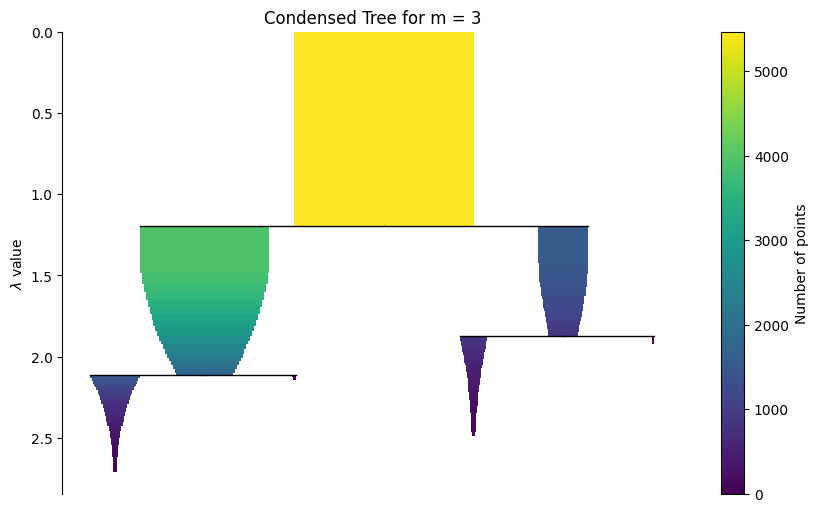

In [8]:
g.plot_condensed_tree(3)

> The widget below is most useful in a live Jupyter environment.

In [9]:
g.interactive_condensed_tree()

SelectionSlider(continuous_update=False, description='m', layout=Layout(width='500px'), options=(2, 3, 4, 5), …